In [1]:
# Goal:
# Explore booking patterns in Bethpage tee time reservations
# to understand demand patterns and identify capacity bottlenecks.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_parquet("../data/cleaned/bethpage_bookings_clean.parquet")
df = df[df["invalid_tee_time"] == False]
display(df.head())
display(df.size)
display(df.columns)




,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time
0,2021-03-14 07:51:00,2021-03-07 19:00:00,played,NaT,weekend,morning,2,Blue,9,124.0,False,False
1,2021-03-14 07:51:00,2021-03-13 21:35:00,played,NaT,weekend,morning,1,Blue,9,31.0,False,False
2,2021-03-14 08:00:00,2021-03-13 15:32:00,played,NaT,weekend,morning,2,Blue,9,62.0,False,False
3,2021-03-14 08:27:00,2021-03-13 11:19:00,played,NaT,weekend,morning,4,Blue,9,124.0,False,False
4,2021-03-14 08:36:00,2021-03-13 17:42:00,played,NaT,weekend,morning,3,Blue,9,93.0,False,False


7391592

Index(['tee_time', 'booking_time', 'status_text', 'date_cancelled',
       'time_of_week', 'time_of_day', 'player_count_final', 'course',
       'round_length', 'cost_per_group', 'invalid_cancellation',
       'invalid_tee_time'],
      dtype='object')

In [2]:
#basic data review & integrity checks
display(df.info())
display(df.describe())
display(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 615966 entries, 0 to 616012
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   tee_time              615966 non-null  datetime64[ns]
 1   booking_time          615966 non-null  datetime64[ns]
 2   status_text           615966 non-null  category      
 3   date_cancelled        308206 non-null  datetime64[ns]
 4   time_of_week          615966 non-null  category      
 5   time_of_day           615966 non-null  category      
 6   player_count_final    615966 non-null  int64         
 7   course                615966 non-null  object        
 8   round_length          615966 non-null  int64         
 9   cost_per_group        599826 non-null  float64       
 10  invalid_cancellation  615966 non-null  bool          
 11  invalid_tee_time      615966 non-null  bool          
dtypes: bool(2), category(3), datetime64[ns](3), float64(1), int64(2

None

,tee_time,booking_time,date_cancelled,player_count_final,round_length,cost_per_group
count,615966,615966,308206,615966.000000,615966.000000,599826.000000
mean,2023-07-01 23:48:48.636969728,2023-06-28 16:14:54.106233856,2023-08-13 07:08:35.910287360,2.620776,15.286613,121.421936
min,2021-03-14 07:51:00,2021-03-07 19:00:00,2021-03-11 14:44:21,1.000000,9.000000,0.000000
25%,2022-07-24 12:00:00,2022-07-21 14:30:15,2022-09-29 11:59:30,1.000000,9.000000,53.000000
50%,2023-07-09 06:03:00,2023-07-05 19:00:00,2023-07-28 12:55:30,2.000000,18.000000,106.000000
75%,2024-06-16 14:36:00,2024-06-13 14:14:45,2024-05-28 19:28:46,4.000000,18.000000,172.000000
max,2025-10-21 14:00:00,2025-10-15 14:44:00,2025-10-15 13:40:01,4.000000,18.000000,660.000000
std,NaN,NaN,NaN,1.287343,4.130138,80.428146


tee_time                     0
booking_time                 0
status_text                  0
date_cancelled          307760
time_of_week                 0
time_of_day                  0
player_count_final           0
course                       0
round_length                 0
cost_per_group           16140
invalid_cancellation         0
invalid_tee_time             0
dtype: int64

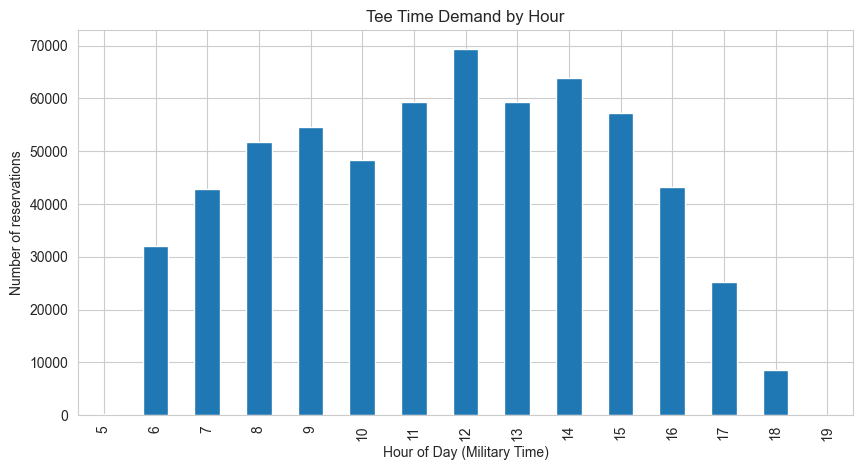

In [3]:
#demand by hour
hourly_demand = df.groupby(df["tee_time"].dt.hour).size()

hourly_demand.plot(kind="bar",figsize=(10,5))
plt.title("Tee Time Demand by Hour")
plt.xlabel("Hour of Day (Military Time)")
plt.ylabel("Number of reservations")
plt.show()

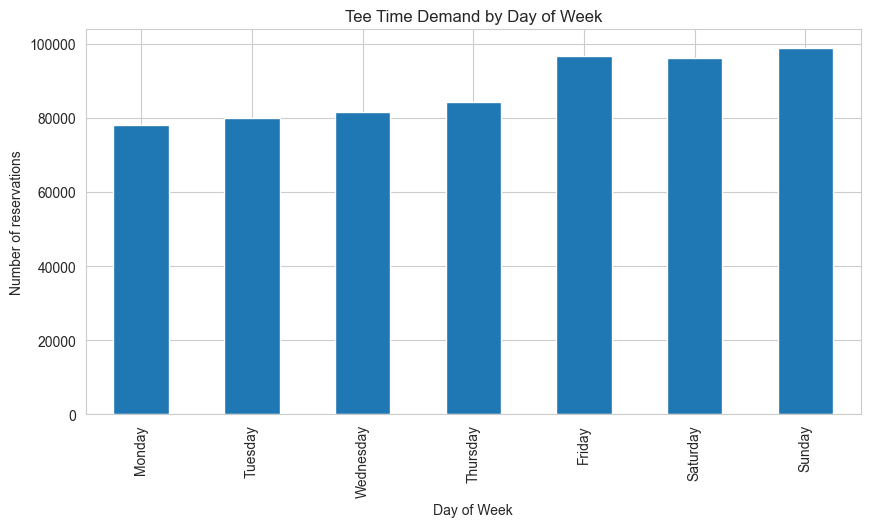

In [4]:
#demand by day of week 
DOW_demand = df.groupby(df["tee_time"].dt.day_name()).size()
day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
DOW_demand = DOW_demand.reindex(day_order)

DOW_demand.plot(kind="bar",figsize=(10,5))
plt.title("Tee Time Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of reservations")
plt.show()


,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
tee_time,,,,,,,
5,57,37,33,23,50,37,28
6,5558,4898,3904,4617,4730,4176,4184
7,6830,6082,4867,5971,6170,6348,6536
8,7569,6874,6312,6951,7542,8108,8383
9,7764,6686,7135,7511,7434,8694,9398
10,6492,5807,6598,6453,7721,7381,7843
11,7629,7284,8272,8369,9564,9264,8993
12,9067,9086,9444,9527,10669,10669,10963
13,6786,8466,8817,8747,9172,8341,8994


Index(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'],
      dtype='object')

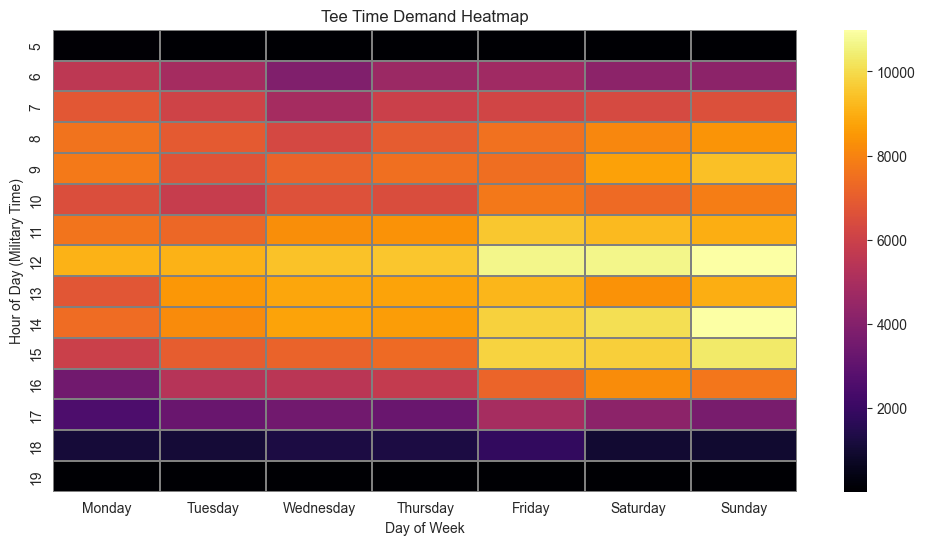

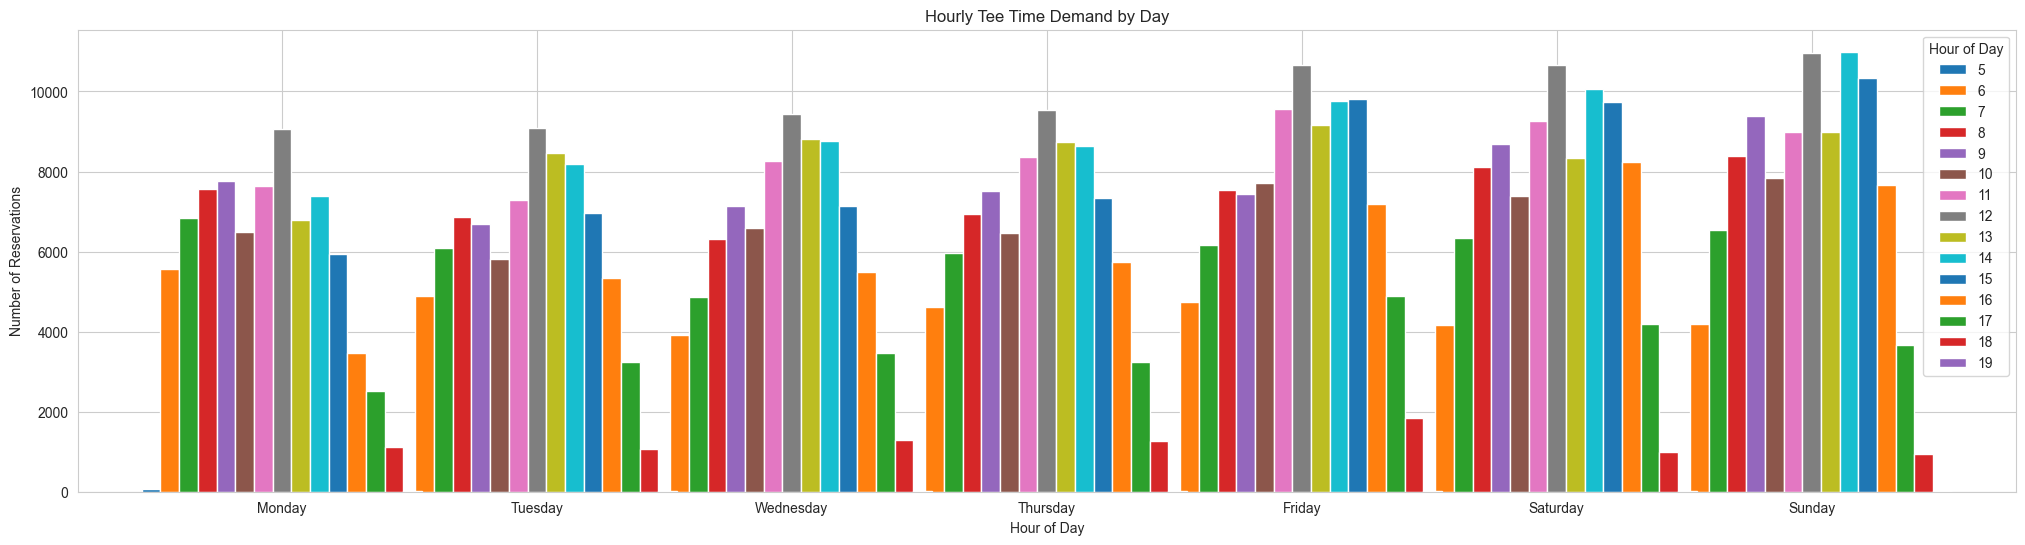

In [5]:
#DOW vs Hour heatmap
heatmap_data = df.groupby([df["tee_time"].dt.hour,df["tee_time"].dt.dayofweek]).size().unstack()
heatmap_data.columns = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
display(heatmap_data)
display(heatmap_data.columns)

#heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time Demand Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Day of Week")
plt.show()

#day by hour bar chart
heatmap_data.T.plot(kind="bar",figsize=(25,6),width=1.1)
plt.title("Hourly Tee Time Demand by Day")
plt.legend(title="Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reservations")
plt.xticks(rotation=0)
plt.show()

,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time
5358,2021-04-16 05:18:00,2021-04-15 18:26:00,unknown,NaT,weekday,morning,4,Yellow,9,172.0,False,False
11572,2021-05-10 05:45:00,2021-05-03 19:30:00,played,NaT,weekday,morning,1,Yellow,9,28.0,False,False
12408,2021-05-13 05:54:00,2021-05-12 21:52:00,played,NaT,weekday,morning,1,Red,18,28.0,False,False
13612,2021-05-16 05:45:00,2021-05-15 22:01:00,played,NaT,weekend,morning,1,Yellow,9,31.0,False,False
14007,2021-05-17 05:45:00,2021-05-16 16:39:00,played,NaT,weekday,morning,1,Red,18,48.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
607872,2025-08-01 05:54:00,2025-07-25 19:03:00,cancelled,2025-08-01 07:09:53,weekday,morning,4,Blue,18,100.0,False,False
608128,2025-08-02 05:54:00,2025-07-26 19:11:00,played,NaT,weekend,morning,1,Yellow,9,NaN,False,False
608384,2025-08-03 05:54:00,2025-07-27 19:00:00,played,NaT,weekend,morning,1,Yellow,9,0.0,False,False
615312,2025-10-13 05:00:00,2025-10-06 19:00:00,cancelled,2025-10-15 09:53:17,weekday,morning,4,Blue,18,172.0,False,False


tee_time
2021    55
2022    46
2023    47
2024    53
2025    64
dtype: int64

tee_time,1,2,3,4,5,6,7,8,9,10,11,12
tee_time,,,,,,,,,,,,
5,8.0,3.0,2.0,6.0,71.0,86.0,57.0,7.0,2.0,3.0,11.0,9.0
6,NaN,NaN,NaN,1883.0,8150.0,9073.0,8464.0,3871.0,626.0,NaN,NaN,NaN
7,NaN,NaN,616.0,7731.0,6809.0,6623.0,6309.0,7397.0,4660.0,2172.0,479.0,8.0
8,2.0,NaN,2614.0,8475.0,5985.0,5388.0,5618.0,4891.0,4970.0,7597.0,6121.0,78.0
9,572.0,699.0,2829.0,6602.0,7488.0,6783.0,6942.0,5693.0,4225.0,4943.0,7022.0,824.0
10,1456.0,1569.0,2385.0,6180.0,5552.0,5492.0,5558.0,4989.0,4751.0,4594.0,4194.0,1575.0
11,1271.0,1231.0,2686.0,7446.0,7443.0,6851.0,6599.0,5977.0,5335.0,6250.0,6706.0,1580.0
12,1724.0,1767.0,3218.0,8377.0,8427.0,7744.0,7681.0,7406.0,6362.0,7222.0,7202.0,2295.0
13,1100.0,1875.0,2876.0,6613.0,7527.0,6984.0,7028.0,6226.0,5362.0,7087.0,5331.0,1314.0


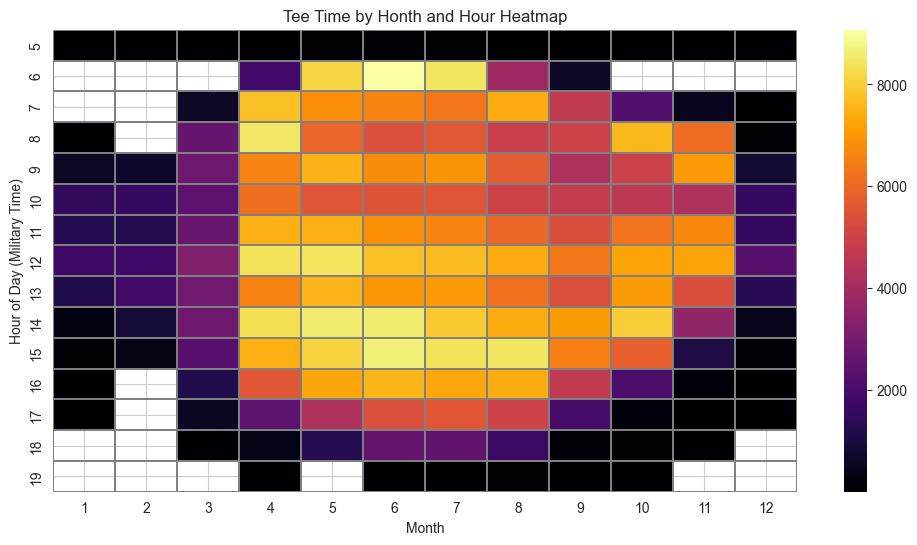

In [6]:
#check odd lack of 5am hour tee times
five_am_res = df[df["tee_time"].dt.hour == 5]
display(five_am_res)
display(five_am_res.groupby(five_am_res["tee_time"].dt.year).size())
#5am times do exist they are just relatively rare, likely due to not being available year round (dst, short spring and fall days)
#also likely undesireable to NYC residents as it takes over an hour to reach the course by car or train

#heatmap of month/hour to confirm daylight restriction theory
early_tee_time_heatmap_data = df.groupby([df["tee_time"].dt.hour,df['tee_time'].dt.month]).size().unstack()
display(early_tee_time_heatmap_data)
plt.figure(figsize=(12,6))
sns.heatmap(early_tee_time_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time by Honth and Hour Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Month")
plt.show()

tee_time,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
tee_time,,,,,,,,,,,,
6.0,NaN,NaN,NaN,1883.0,8150.0,9073.0,8464.0,3871.0,626.0,NaN,NaN,NaN
7.0,NaN,NaN,616.0,7731.0,6809.0,6623.0,6309.0,7397.0,4660.0,2172.0,479.0,8.0
8.0,2.0,NaN,2614.0,8475.0,5985.0,5388.0,5618.0,4891.0,4970.0,7597.0,6121.0,78.0
9.0,572.0,699.0,2829.0,6602.0,7488.0,6783.0,6942.0,5693.0,4225.0,4943.0,7022.0,824.0
10.0,1456.0,1569.0,2385.0,6180.0,5552.0,5492.0,5558.0,4989.0,4751.0,4594.0,4194.0,1575.0
11.0,1271.0,1231.0,2686.0,7446.0,7443.0,6851.0,6599.0,5977.0,5335.0,6250.0,6706.0,1580.0
12.0,1724.0,1767.0,3218.0,8377.0,8427.0,7744.0,7681.0,7406.0,6362.0,7222.0,7202.0,2295.0
13.0,1100.0,1875.0,2876.0,6613.0,7527.0,6984.0,7028.0,6226.0,5362.0,7087.0,5331.0,1314.0
14.0,274.0,905.0,2827.0,8317.0,8542.0,8549.0,7905.0,7395.0,7073.0,7983.0,3545.0,465.0


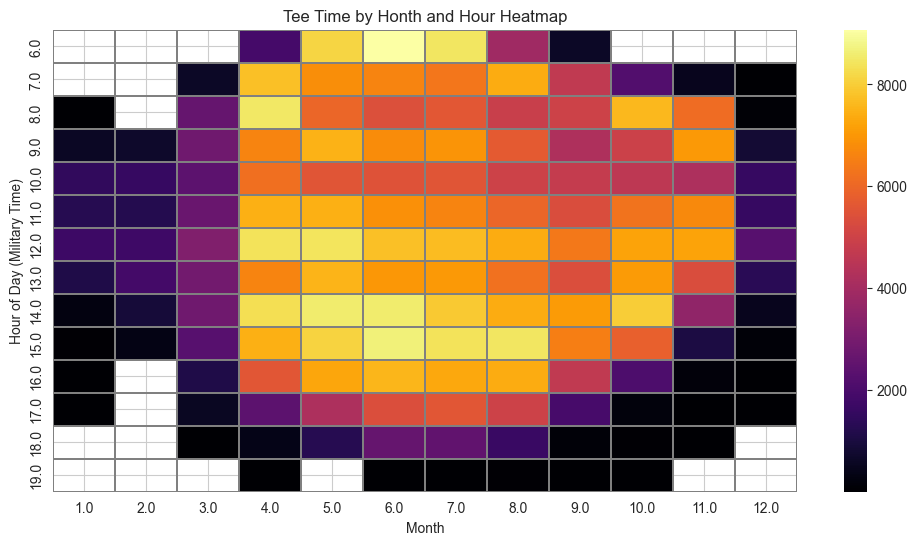

In [7]:
#remove 265 5am tee times as many seem to be data errors. Not possible most of the year when the sun is not up betwen 5am and 6am
df2 = df[df["tee_time"].dt.hour != 5].copy()

#updated heatmap of month/hour to confirm daylight restriction theory
early_tee_time_heatmap_data = df.groupby([df2["tee_time"].dt.hour,df2['tee_time'].dt.month]).size().unstack()
display(early_tee_time_heatmap_data)
plt.figure(figsize=(12,6))
sns.heatmap(early_tee_time_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Tee Time by Honth and Hour Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Month")
plt.show()

In [8]:
#investigate invalid_cancellation rows to determine if they are biasing demand analysis
df["invalid_cancellation"].value_counts(normalize=True)

#small proportion of data makes True rows OK to include. Will remove from cancellation analysis to avoid NAT errors


invalid_cancellation
False    0.998742
True     0.001258
Name: proportion, dtype: float64

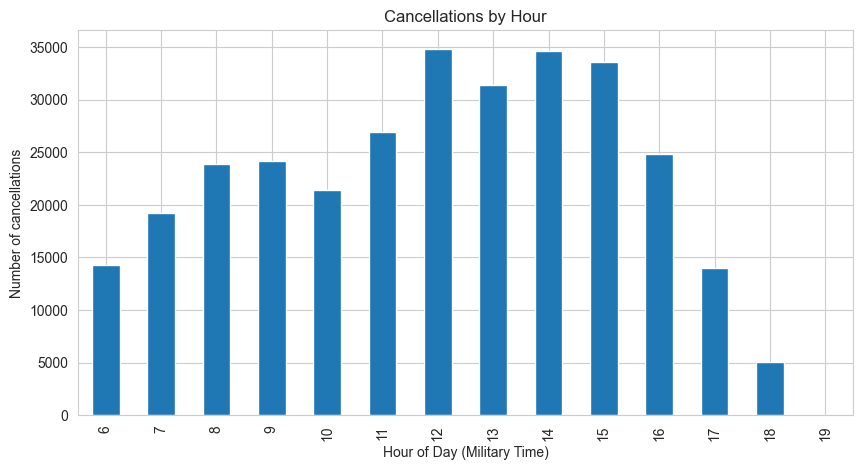

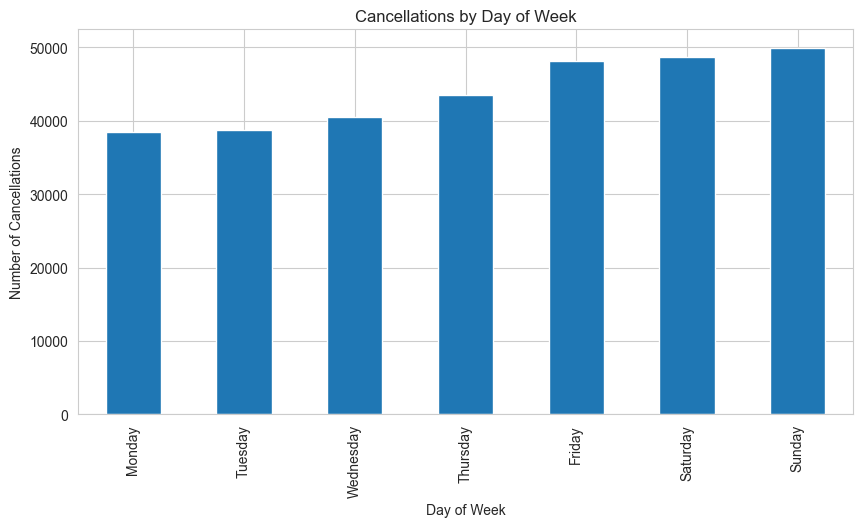

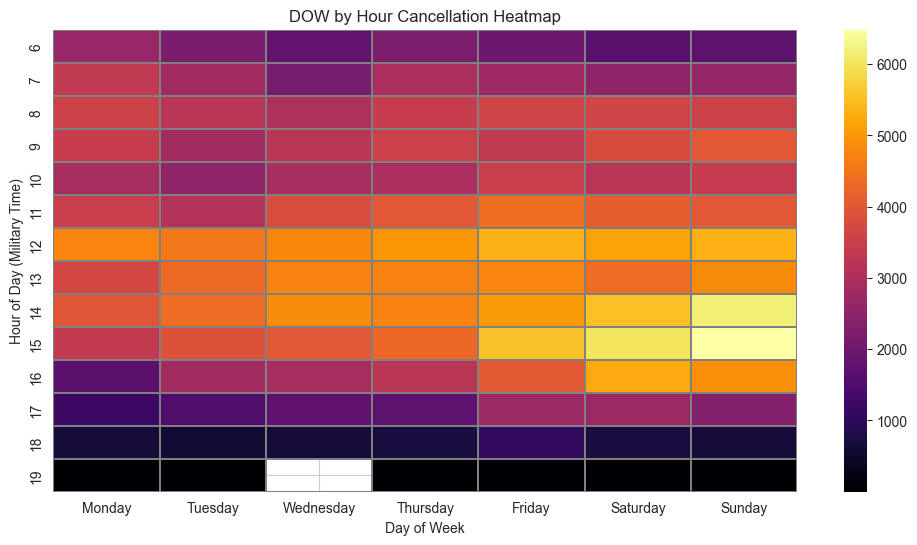

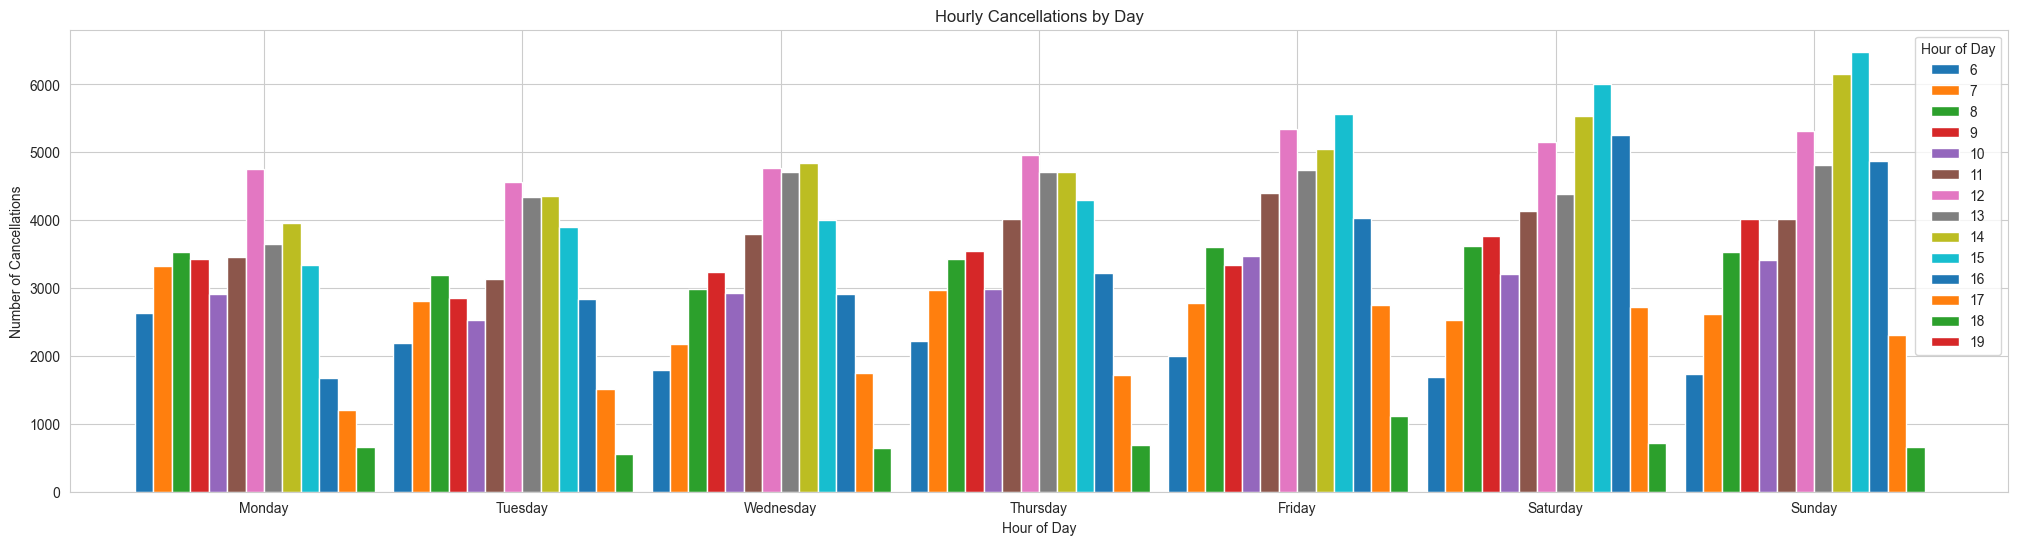

tee_time,1,2,3,4,5,6,7,8,9,10,11,12
tee_time,,,,,,,,,,,,
6,NaN,NaN,NaN,1006.0,4063.0,4094.0,3424.0,1464.0,211.0,NaN,NaN,NaN
7,NaN,NaN,311.0,4356.0,3186.0,2676.0,2383.0,3199.0,1883.0,965.0,233.0,8.0
8,NaN,NaN,1528.0,4617.0,2620.0,2128.0,2063.0,1788.0,2098.0,3440.0,3576.0,35.0
9,364.0,488.0,1547.0,3244.0,3307.0,2628.0,2705.0,2080.0,1664.0,2000.0,3706.0,439.0
10,976.0,1038.0,1214.0,2959.0,2339.0,2247.0,2287.0,1918.0,1899.0,1899.0,1801.0,853.0
11,828.0,755.0,1339.0,3713.0,3351.0,2838.0,2837.0,2464.0,2270.0,2569.0,3185.0,814.0
12,1229.0,1145.0,1686.0,4353.0,4013.0,3495.0,3559.0,3146.0,2922.0,3498.0,4318.0,1490.0
13,809.0,1369.0,1678.0,3502.0,3717.0,3272.0,3338.0,2786.0,2567.0,3724.0,3707.0,881.0
14,172.0,620.0,1653.0,4734.0,4394.0,4117.0,3850.0,3413.0,3782.0,5169.0,2426.0,274.0


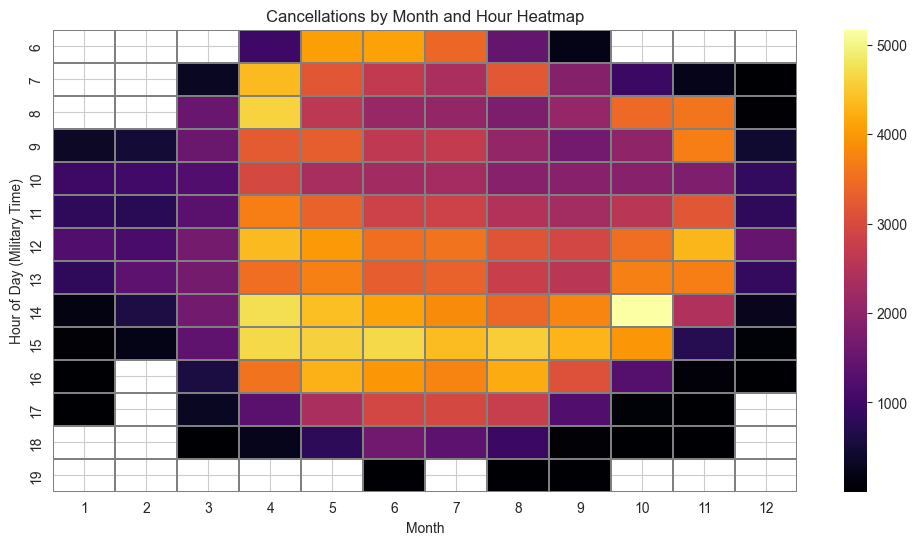

In [9]:
#plot matching graphs to examine which tee times are most commonly cancelled
df2_cancellation = df2[(df2["invalid_cancellation"] == False) & (df2["status_text"]=="cancelled")]

#cancellations by hour of day
hourly_cancellations = df2_cancellation.groupby(df2_cancellation["tee_time"].dt.hour).size()

hourly_cancellations.plot(kind="bar",figsize=(10,5))
plt.title("Cancellations by Hour")
plt.xlabel("Hour of Day (Military Time)")
plt.ylabel("Number of cancellations")
plt.show()

#cancellations by day of week 
DOW_cancellations = df2_cancellation.groupby(df2_cancellation["tee_time"].dt.day_name()).size()
day_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]
DOW_cancellations = DOW_cancellations.reindex(day_order)

DOW_cancellations.plot(kind="bar",figsize=(10,5))
plt.title("Cancellations by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Cancellations")
plt.show()

#DOW vs Hour heatmap data
dow_cancel_heatmap_data = df2_cancellation.groupby([df2_cancellation["tee_time"].dt.hour,df2_cancellation["tee_time"].dt.dayofweek]).size().unstack()
dow_cancel_heatmap_data.columns = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

#heatmap cancellations DOW
plt.figure(figsize=(12,6))
sns.heatmap(dow_cancel_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("DOW by Hour Cancellation Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Day of Week")
plt.show()

#cancellations day by hour bar chart
dow_cancel_heatmap_data.T.plot(kind="bar",figsize=(25,6),width=1.0)
plt.title("Hourly Cancellations by Day")
plt.legend(title="Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=0)
plt.show()

#cancellations by month and hour of day heatmap
monthly_cancellaions_heatmap_data = df2_cancellation.groupby([df2_cancellation["tee_time"].dt.hour,df2_cancellation['tee_time'].dt.month]).size().unstack()
display(monthly_cancellaions_heatmap_data)
plt.figure(figsize=(12,6))
sns.heatmap(monthly_cancellaions_heatmap_data,cmap="inferno",linecolor="gray",linewidths=.1)
plt.title("Cancellations by Month and Hour Heatmap")
plt.ylabel("Hour of Day (Military Time)")
plt.xlabel("Month")
plt.show()

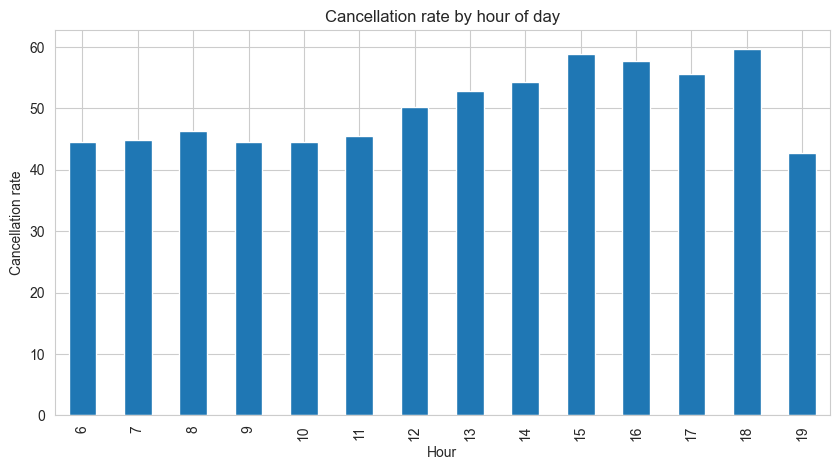

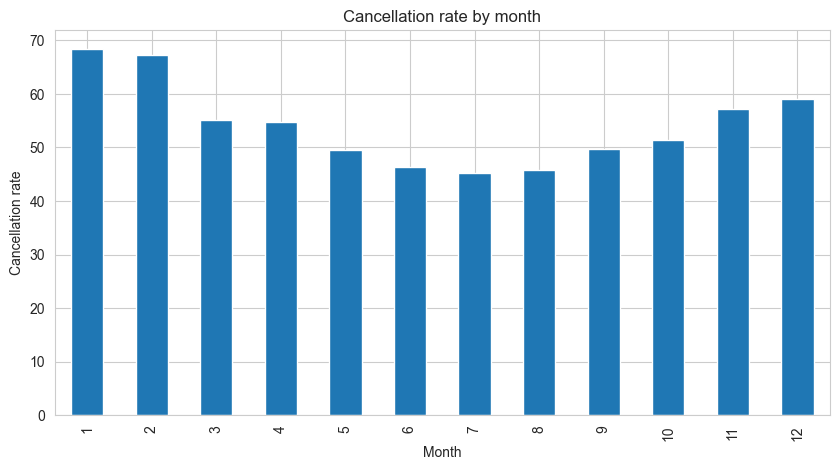

In [10]:
#check cancellation rate by month and hour to identify if it is non-constant
#hour
bookings_by_hour = df2.groupby(df2["tee_time"].dt.hour)["tee_time"].count()
cancellations_by_hour = df2[df2["status_text"] == "cancelled"].groupby(df2["tee_time"].dt.hour)["tee_time"].count()
cancellation_rate_hour = round((cancellations_by_hour/bookings_by_hour)*100,2)
rate_hour_mean = cancellation_rate_hour.mean()

cancellation_rate_hour.plot(kind="bar",figsize=(10,5))
plt.title("Cancellation rate by hour of day")
plt.xlabel("Hour")
plt.ylabel("Cancellation rate")
plt.show()

#month
bookings_by_month = df2.groupby(df2["tee_time"].dt.month)["tee_time"].count()
cancellations_by_month = df2[df2["status_text"] == "cancelled"].groupby(df2["tee_time"].dt.month)["tee_time"].count()
cancellation_rate_month = round((cancellations_by_month/bookings_by_month)*100,2)
rate_month_mean = cancellation_rate_month.mean()

cancellation_rate_month.plot(kind="bar",figsize=(10,5))
plt.title("Cancellation rate by month")
plt.xlabel("Month")
plt.ylabel("Cancellation rate")
plt.show()

In [19]:
#add time before tee time metric to cancelled tee times
df2["cancellation_lead_time"] = df2["tee_time"]-df2["date_cancelled"]

df2["cancellation_lead_time"].describe()

#investigate illogcial lead times
negative_lt = df2[(df2["cancellation_lead_time"] < pd.Timedelta(0))]
display(negative_lt)
long_lt = df2[(df2["cancellation_lead_time"] > pd.Timedelta(days=7))]
display(long_lt)

,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time,cancellation_lead_time
1063,2021-03-25 07:33:00,2021-03-24 23:19:00,cancelled,2021-03-25 13:17:34,weekday,morning,1,Yellow,9,28.0,False,False,-1 days +18:15:26
1609,2021-03-28 07:51:00,2021-03-27 15:50:00,cancelled,2021-03-28 08:22:18,weekend,morning,2,Green,18,96.0,False,False,-1 days +23:28:42
1814,2021-03-30 08:00:00,2021-03-29 17:49:00,cancelled,2021-03-30 08:59:50,weekday,morning,2,Blue,9,56.0,False,False,-1 days +23:00:10
2057,2021-03-31 07:42:00,2021-03-29 11:05:00,cancelled,2021-03-31 07:47:30,weekday,morning,1,Yellow,9,28.0,False,False,-1 days +23:54:30
5360,2021-04-16 06:48:00,2021-04-15 14:24:00,cancelled,2021-04-16 11:13:56,weekday,morning,1,Yellow,9,28.0,False,False,-1 days +19:34:04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
615366,2025-10-13 11:09:00,2025-10-06 19:00:00,cancelled,2025-10-13 11:29:18,weekday,midday,3,Blue,18,0.0,False,False,-1 days +23:39:42
615370,2025-10-13 11:45:00,2025-10-06 19:11:00,cancelled,2025-10-15 09:32:16,weekday,midday,4,Red,18,192.0,False,False,-2 days +02:12:44
615398,2025-10-13 13:42:00,2025-10-06 19:01:00,cancelled,2025-10-13 16:43:49,weekday,midday,4,Red,18,192.0,False,False,-1 days +20:58:11
615404,2025-10-13 13:51:00,2025-10-07 16:05:00,cancelled,2025-10-15 09:41:05,weekday,midday,2,Blue,18,52.0,False,False,-2 days +04:09:55


,tee_time,booking_time,status_text,date_cancelled,time_of_week,time_of_day,player_count_final,course,round_length,cost_per_group,invalid_cancellation,invalid_tee_time,cancellation_lead_time
20535,2021-09-22 17:27:00,2021-09-15 19:00:00,cancelled,2021-09-15 17:03:00,weekday,evening,4,Yellow,9,NaN,False,False,7 days 00:24:00
21320,2021-09-19 17:18:00,2021-09-12 19:00:00,cancelled,2021-09-12 17:02:00,weekend,evening,4,Green,18,NaN,False,False,7 days 00:16:00
106695,2022-05-21 17:09:00,2022-05-14 19:00:00,cancelled,2022-05-14 17:01:29,weekend,evening,4,Red,18,NaN,False,False,7 days 00:07:31
107498,2022-05-22 17:09:00,2022-05-15 19:01:00,cancelled,2022-05-15 17:02:00,weekend,evening,3,Red,18,NaN,False,False,7 days 00:07:00
117811,2022-06-05 17:36:00,2022-05-29 19:00:00,cancelled,2022-05-29 17:01:04,weekend,evening,4,Green,18,NaN,False,False,7 days 00:34:56
120606,2022-06-09 17:36:00,2022-06-02 19:00:00,cancelled,2022-06-02 17:01:00,weekday,evening,3,Green,18,NaN,False,False,7 days 00:35:00
125702,2022-06-16 17:36:00,2022-06-09 19:00:00,cancelled,2022-06-09 17:00:51,weekday,evening,4,Green,18,NaN,False,False,7 days 00:35:09
126529,2022-06-17 17:09:00,2022-06-10 19:02:00,cancelled,2022-06-10 17:02:41,weekday,evening,1,Green,18,NaN,False,False,7 days 00:06:19
128147,2022-06-19 17:36:00,2022-06-12 19:01:00,cancelled,2022-06-12 17:02:19,weekend,evening,4,Green,18,NaN,False,False,7 days 00:33:41
128609,2022-06-20 17:18:00,2022-06-13 19:00:00,cancelled,2022-06-13 17:01:08,weekday,evening,3,Blue,18,NaN,False,False,7 days 00:16:52
